Analyst Dataset

--- THỐNG KÊ CHI TIẾT ---
Số lượng: 
label
ham     3672
spam    1499
Name: count, dtype: int64

Tỉ lệ phần trăm: 
label
ham     71.01141
spam    28.98859
Name: proportion, dtype: float64


/tmp/ipykernel_6854/3656657472.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


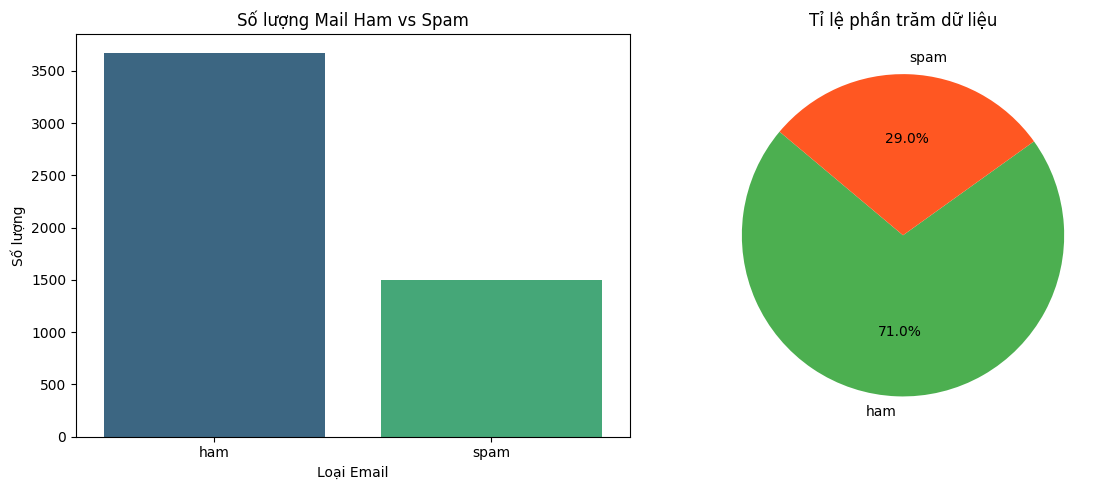

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ĐỌC DỮ LIỆU
PATH_DATA_CSV = '/content/drive/MyDrive/Colab Notebooks/Spam Mail/spam_ham_dataset.csv'
df = pd.read_csv(PATH_DATA_CSV)

# 2. ĐẾM SỐ LƯỢNG
# Giả sử cột nhãn của bạn là 'label' (chứa chữ 'ham', 'spam')
counts = df['label'].value_counts()
percent = df['label'].value_counts(normalize=True) * 100

print("--- THỐNG KÊ CHI TIẾT ---")
print(f"Số lượng: \n{counts}")
print(f"\nTỉ lệ phần trăm: \n{percent}")

# 3. VẼ BIỂU ĐỒ
plt.figure(figsize=(12, 5))

# Biểu đồ cột (Count Plot)
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Số lượng Mail Ham vs Spam')
plt.xlabel('Loại Email')
plt.ylabel('Số lượng')

# Biểu đồ tròn (Pie Chart) để thấy tỉ lệ %
plt.subplot(1, 2, 2)
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=['#4CAF50', '#FF5722'])
plt.title('Tỉ lệ phần trăm dữ liệu')

plt.tight_layout()
plt.show()

Can be seen that the dataset is not balanced.

Vòng lặp 0...
Vòng lặp 500...
Vòng lặp 1000...
Vòng lặp 1500...
Vòng lặp 2000...
Vòng lặp 2500...
Huấn luyện xong!


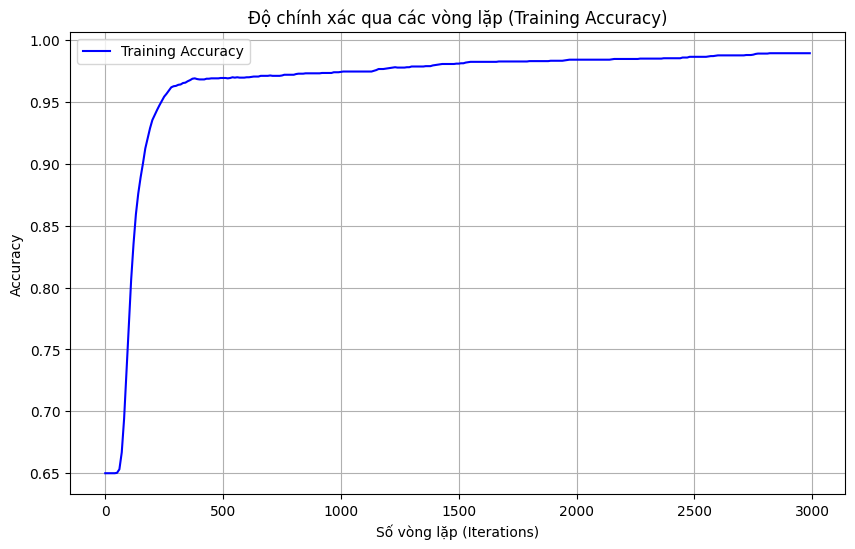

Đã xuất mô hình thành công tại: logistic_custom_model.pkl


In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt # Thêm thư viện vẽ biểu đồ
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

# ==========================================
# 1. ĐỊNH NGHĨA CLASS (ĐÃ CẬP NHẬT ĐỂ LƯU LỊCH SỬ)
# ==========================================
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.5, iterations=2000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.history = [] # Lưu độ chính xác qua từng vòng lặp

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        return [1 if i > 0.5 else 0 for i in y_predicted]

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.iterations):
            # Tính toán Gradient
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Cập nhật trọng số
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Ghi lại độ chính xác sau mỗi vòng lặp (Lưu ý: Tính toán này làm chậm quá trình train một chút)
            if i % 10 == 0: # Cứ 10 vòng lặp lưu 1 lần để tối ưu tốc độ
                y_pred_labels = [1 if p > 0.5 else 0 for p in y_predicted]
                acc = np.mean(y_pred_labels == y)
                self.history.append(acc)

            if i % 500 == 0:
                print(f"Vòng lặp {i}...")

# ==========================================
# 2. XỬ LÝ DỮ LIỆU
# ==========================================
# (Phần này giữ nguyên như code của bạn)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Spam Mail/spam_ham_dataset.csv')
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=42)

df_spam_train = df_train_full[df_train_full['label_num'] == 1]
df_ham_train = df_train_full[df_train_full['label_num'] == 0]

n_spam = len(df_spam_train)
n_ham_needed = int((n_spam / 0.35) - n_spam)
df_ham_train_downsampled = df_ham_train.sample(n=min(n_ham_needed, len(df_ham_train)), random_state=42)

df_train_final = pd.concat([df_spam_train, df_ham_train_downsampled]).sample(frac=1, random_state=42)
X_train_raw = df_train_final['text'].astype(str).values
y_train = df_train_final['label_num'].values

# ==========================================
# 3. VECTOR HÓA VÀ HUẤN LUYỆN
# ==========================================
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(X_train_raw).toarray()

model = LogisticRegressionScratch(learning_rate=1.0, iterations=3000)
model.fit(X_train, y_train)
print("Huấn luyện xong!")

# ==========================================
# 4. VẼ BIỂU ĐỒ ĐỘ CHÍNH XÁC
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(range(0, len(model.history) * 10, 10), model.history, color='blue', label='Training Accuracy')
plt.title('Độ chính xác qua các vòng lặp (Training Accuracy)')
plt.xlabel('Số vòng lặp (Iterations)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# ==========================================
# 5. XUẤT MÔ HÌNH
# ==========================================
model_data = {
    'weights': model.weights,
    'bias': model.bias,
    'vocabulary': vectorizer.vocabulary_,
    'idf': vectorizer.idf_
}

filename = "logistic_custom_model.pkl"
with open(filename, 'wb') as f:
    pickle.dump(model_data, f)

print(f"Đã xuất mô hình thành công tại: {filename}")

Đã tải mô hình thành công!

KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST GỐC
Độ chính xác (Accuracy): 98.07%

Báo cáo chi tiết (Classification Report):
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       742
        Spam       0.95      0.99      0.97       293

    accuracy                           0.98      1035
   macro avg       0.97      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035



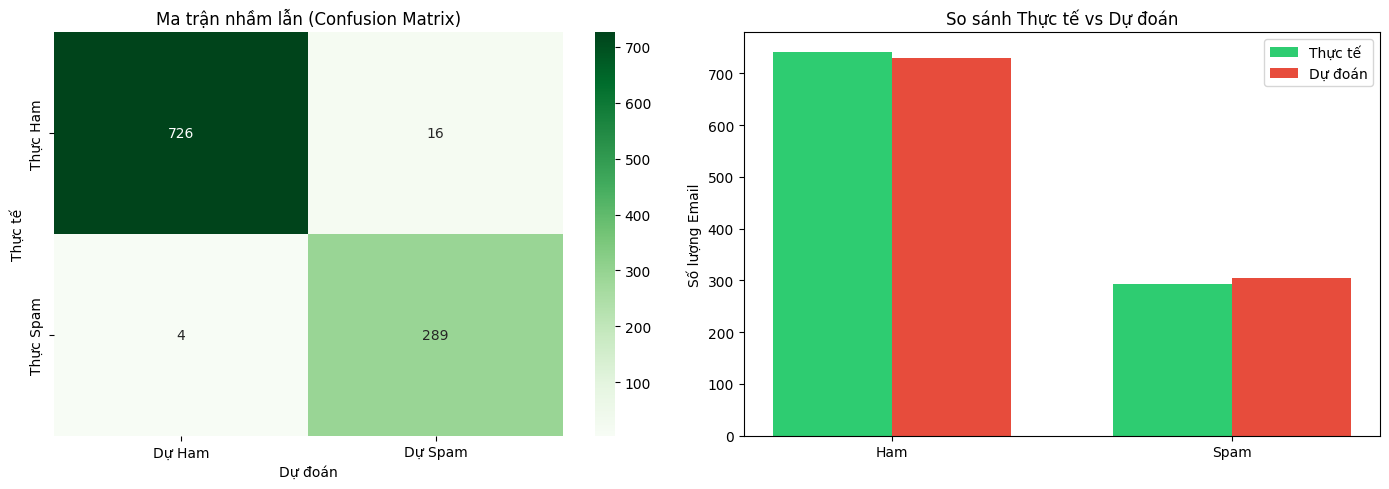

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ==========================================
# 1. ĐƯỜNG DẪN (Vui lòng kiểm tra lại đường dẫn của bạn)
# ==========================================
PATH_MODEL_PKL = '/content/drive/MyDrive/Colab Notebooks/Spam Mail/logistic_custom_model.pkl'
PATH_DATA_CSV = '/content/drive/MyDrive/Colab Notebooks/Spam Mail/spam_ham_dataset.csv'

# ==========================================
# 2. LOAD MODEL VÀ DỮ LIỆU GỐC
# ==========================================
# Load tham số từ file .pkl
try:
    with open(PATH_MODEL_PKL, 'rb') as f:
        model_data = pickle.load(f)
    print("Đã tải mô hình thành công!")
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file tại {PATH_MODEL_PKL}")

weights = model_data['weights']
bias = model_data['bias']
vocab = model_data['vocabulary']
saved_idf = model_data['idf']

# Load dữ liệu gốc để tách tập Test
df = pd.read_csv(PATH_DATA_CSV)
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})
X_text = df['text'].astype(str).values
y = df['label_num'].values

# QUAN TRỌNG: Dùng đúng random_state=42 và test_size=0.2 để lấy đúng tập Test
# mà mô hình chưa bao giờ nhìn thấy trong lúc Train.
_, X_test_raw, _, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# ==========================================
# 3. TÁI TẠO VECTORIZER VÀ DỰ ĐOÁN
# ==========================================
# Khởi tạo Vectorizer chỉ với Vocabulary và IDF đã lưu (KHÔNG fit lại)
vectorizer = TfidfVectorizer(vocabulary=vocab)
vectorizer.idf_ = saved_idf

# Biến đổi tập test sang dạng số
X_test = vectorizer.transform(X_test_raw).toarray()

# Hàm tính toán Logic thủ công
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def predict(X, w, b):
    # Phép toán: y = sigmoid(X * w + b)
    linear_model = np.dot(X, w) + b
    y_prob = sigmoid(linear_model)
    return np.array([1 if i > 0.5 else 0 for i in y_prob])

# Chạy dự đoán trên tập Test
y_pred = predict(X_test, weights, bias)

# ==========================================
# 4. ĐÁNH GIÁ VÀ VẼ BIỂU ĐỒ
# ==========================================
acc = accuracy_score(y_test, y_pred)
print("\n" + "="*40)
print(f"KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST GỐC")
print(f"Độ chính xác (Accuracy): {acc*100:.2f}%")
print("="*40)
print("\nBáo cáo chi tiết (Classification Report):")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Biểu đồ 1: Confusion Matrix
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dự Ham', 'Dự Spam'],
            yticklabels=['Thực Ham', 'Thực Spam'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')

# Biểu đồ 2: So sánh số lượng
plt.subplot(1, 2, 2)
labels = ['Ham', 'Spam']
actual_counts = [np.sum(y_test == 0), np.sum(y_test == 1)]
pred_counts = [np.sum(y_pred == 0), np.sum(y_pred == 1)]

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, actual_counts, width, label='Thực tế', color='#2ecc71')
plt.bar(x + width/2, pred_counts, width, label='Dự đoán', color='#e74c3c')

plt.ylabel('Số lượng Email')
plt.title('So sánh Thực tế vs Dự đoán')
plt.xticks(x, labels)
plt.legend()

plt.tight_layout()
plt.show()

### 5. Thử nghiệm với văn bản mới

In [1]:
# 1. Nhập văn bản mới
new_email_text = "Congratulations! You've won a free iPhone. Click here to claim your prize!"
print(f"Văn bản đầu vào: {new_email_text}")

Văn bản đầu vào: Congratulations! You've won a free iPhone. Click here to claim your prize!


In [4]:
# 1. Nhập các thư viện cần thiết cho phần dự đoán này
import numpy as np
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

# 2. Định nghĩa đường dẫn tới model đã lưu
# Đảm bảo đường dẫn này khớp với vị trí file .pkl của bạn
PATH_MODEL_PKL = '/content/drive/MyDrive/Colab Notebooks/Spam Mail/logistic_custom_model.pkl'

# 3. Tải model và các thành phần cần thiết từ file .pkl
try:
    with open(PATH_MODEL_PKL, 'rb') as f:
        model_data = pickle.load(f)
    print("Đã tải mô hình thành công cho khối dự đoán!")
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file tại {PATH_MODEL_PKL}. Vui lòng kiểm tra lại đường dẫn.")
    raise # Dừng thực thi nếu không tìm thấy file

# Gán các tham số đã tải vào các biến toàn cục trong khối này
weights = model_data['weights']
bias = model_data['bias']
vocab = model_data['vocabulary']
saved_idf = model_data['idf']

# 4. Tái tạo Vectorizer sử dụng vocabulary và IDF đã lưu (KHÔNG fit lại)
vectorizer = TfidfVectorizer(vocabulary=vocab)
vectorizer.idf_ = saved_idf

# 5. Định nghĩa lại hàm sigmoid và predict để đảm bảo chúng có sẵn trong phạm vi này
def sigmoid(z):
    # Sử dụng np.clip để ngăn chặn tràn số với các giá trị z quá lớn hoặc quá nhỏ
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def predict(X, w, b):
    # Thực hiện phép toán tuyến tính và hàm sigmoid
    linear_model = np.dot(X, w) + b
    y_prob = sigmoid(linear_model)
    # Chuyển đổi xác suất thành nhãn nhị phân (0 hoặc 1)
    return np.array([1 if i > 0.5 else 0 for i in y_prob])

# new_email_text được định nghĩa ở cell trước (6311531d)
# 6. Tiền xử lý văn bản mới bằng cùng một vectorizer đã tải
X_new = vectorizer.transform([new_email_text]).toarray()

Đã tải mô hình thành công cho khối dự đoán!


In [7]:
# Thử nghiệm với một ví dụ khác
new_email_text_2 = "We detected a new sign-in attempt to your MyPaymentVault account. Please confirm your identity below if this wasn't you."
print(f"\nVăn bản đầu vào: {new_email_text_2}")
X_new_2 = vectorizer.transform([new_email_text_2]).toarray()
prediction_2 = predict(X_new_2, weights, bias)
result_2 = 'Spam' if prediction_2[0] == 1 else 'Ham'
print(f"Dự đoán cho văn bản mới là: {result_2}")


Văn bản đầu vào: We detected a new sign-in attempt to your MyPaymentVault account. Please confirm your identity below if this wasn't you.
Dự đoán cho văn bản mới là: Spam
